In [1]:
import vrep 
import sys
import time 
import numpy as np
from tank import *

import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [2]:
vrep.simxFinish(-1) # closes all opened connections, in case any prevoius wasnt finished
clientID=vrep.simxStart('127.0.0.1',19997,True,True,5000,5) # start a connection

if clientID!=-1:
    print ("Connected to remote API server")
else:
    print("Not connected to remote API server")
    sys.exit("Could not connect")

#create instance of Tank
tank=Tank(clientID)

Connected to remote API server


In [3]:
proximity_sensors=["EN","ES","NE","NW","SE","SW","WN","WS"]
proximity_sensors_handles=[0]*8

# get handle to proximity sensors
for i in range(len(proximity_sensors)):
    err_code,proximity_sensors_handles[i] = vrep.simxGetObjectHandle(clientID,"Proximity_sensor_"+proximity_sensors[i], vrep.simx_opmode_blocking)

err_code,tank_handle = vrep.simxGetObjectHandle(clientID,'Edgeless', vrep.simx_opmode_blocking)

#read and print values from proximity sensors
#first reading should be done with simx_opmode_streaming, further with simx_opmode_buffer parameter
for sensor_name, sensor_handle in zip(proximity_sensors,proximity_sensors_handles):
        err_code,detectionState,detectedPoint,detectedObjectHandle,detectedSurfaceNormalVector=vrep.simxReadProximitySensor(clientID,sensor_handle,vrep.simx_opmode_streaming)
        # print(err_code, detectionState, detectedPoint, detectedObjectHandle, detectedSurfaceNormalVector)

In [4]:
err_code,tank_handle = vrep.simxGetObjectHandle(clientID,'Edgeless', vrep.simx_opmode_blocking)
err_code,lin_velo,ang_velo = vrep.simxGetObjectVelocity(clientID,tank_handle, vrep.simx_opmode_blocking)

In [5]:
tank.forward(5)

#continue reading and printing values from proximity sensors
t = time.time()
while (time.time()-t)<5: # read values for 5 seconds
    for sensor_name, sensor_handle in zip(proximity_sensors,proximity_sensors_handles):
        err_code,detectionState,detectedPoint,detectedObjectHandle,detectedSurfaceNormalVector=vrep.simxReadProximitySensor(clientID,sensor_handle,vrep.simx_opmode_buffer )
        if(err_code == 0):
            print("Proximity_sensor_"+sensor_name, np.linalg.norm(detectedPoint))
    print()
    break

Proximity_sensor_EN 1.025308822585902
Proximity_sensor_ES 1.0983073777570844
Proximity_sensor_NE 3.249403231155598
Proximity_sensor_NW 2.7832457878712087
Proximity_sensor_SE 1.4808624539165283
Proximity_sensor_SW 1.4808624539165283
Proximity_sensor_WN 1.956812572649245
Proximity_sensor_WS 1.956812572649245



## Don't hit the wall

In [6]:
distance = ctrl.Antecedent(np.arange(0.5, 2, 0.001), 'distance')
velocity = ctrl.Antecedent(np.arange(0, 0.75, 0.001), 'velocity')
breaking = ctrl.Consequent(np.arange(0, 3, 1), 'breaking')

distance.automf(3)
velocity.automf(3)
breaking.automf(3)

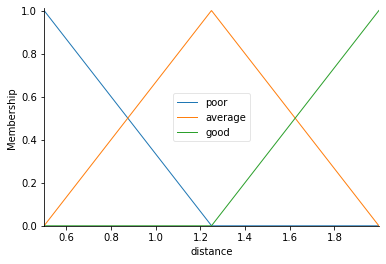

In [16]:
distance.view()

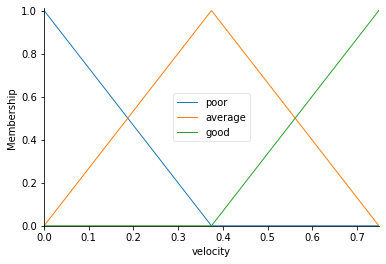

In [8]:
velocity.view()

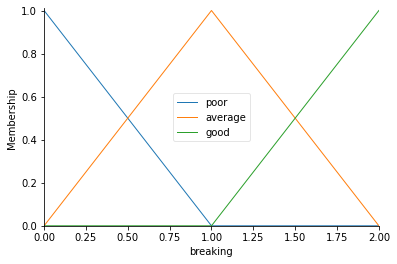

In [9]:
breaking.view()

(<Figure size 432x288 with 1 Axes>, <AxesSubplot:>)

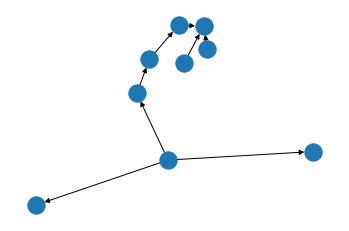

In [10]:
rule1 = ctrl.Rule(distance['poor'], breaking['good'])
rule2 = ctrl.Rule(distance['average'] & velocity['good'], breaking['average'])
rule3 = ctrl.Rule(distance['average'] & (velocity['average'] | velocity['poor']), breaking['poor'])
rule4 = ctrl.Rule(distance['good'], breaking['poor'])

rule1.view()

In [11]:
breaking_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4])
breaking_force = ctrl.ControlSystemSimulation(breaking_ctrl)

In [12]:
# Pass inputs to the ControlSystem using Antecedent labels with Pythonic API
# Note: if you like passing many inputs all at once, use .inputs(dict_of_data)
breaking_force.input['distance'] = 0.55
breaking_force.input['velocity'] = 0.5

# Crunch the numbers
breaking_force.compute()

1.5162494457188418


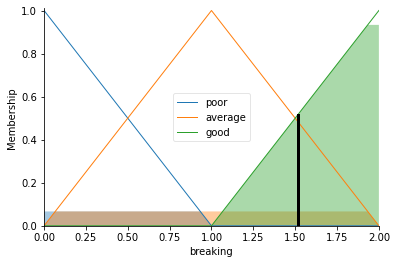

In [13]:
print(breaking_force.output['breaking'])
breaking.view(sim=breaking_force)

In [14]:
current_speed = 0
while True:
    err_code,detectionState,detectedPoint,detectedObjectHandle,detectedSurfaceNormalVector=vrep.simxReadProximitySensor(clientID,proximity_sensors_handles[2],vrep.simx_opmode_buffer)
    err_code,lin_velo,ang_velo = vrep.simxGetObjectVelocity(clientID,tank_handle, vrep.simx_opmode_buffer)

    breaking_force.input['distance'] = detectedPoint[2]
    breaking_force.input['velocity'] = lin_velo[1]
    # Crunch the numbers
    breaking_force.compute()
    force = breaking_force.output['breaking']

    if force > 1.5:
        tank.stop()
        print('stopped')
        break
    
    elif force > 0.8:
        tank.forward(5)
        if current_speed != 5:
            current_speed = 5
            print(f'moderate speed')
    else:
        tank.forward(10)
        if current_speed != 10:
            current_speed = 10
            print(f'high speed')

high speed
moderate speed
stopped


# Parking

In [5]:
distance_2 = ctrl.Antecedent(np.arange(0.5, 3.2, 0.001), 'distance_2')
distance_3 = ctrl.Antecedent(np.arange(0.5, 3.2, 0.001), 'distance_3')
distance_4 = ctrl.Antecedent(np.arange(0.5, 3.2, 0.001), 'distance_4')
turning = ctrl.Consequent(np.arange(0, 3, 1), 'turning')
breaking = ctrl.Consequent(np.arange(0, 3, 1), 'breaking')

distance_2.automf(3)
distance_3.automf(3)
distance_4.automf(3)
turning.automf(3)
breaking.automf(3)

In [6]:
rule1 = ctrl.Rule(distance_2['good'] & distance_3['good'], turning['good'])
rule2 = ctrl.Rule(distance_2['average'] & distance_3['good'], turning['average'])

rule3 = ctrl.Rule(distance_3['poor'] & distance_4['poor'], breaking['good'])
rule4 = ctrl.Rule(distance_3['good'] & distance_4['good'], breaking['poor'])

turning_ctrl = ctrl.ControlSystem([rule1, rule2])
turning_force = ctrl.ControlSystemSimulation(turning_ctrl)

breaking_ctrl = ctrl.ControlSystem([rule3, rule4])
breaking_force = ctrl.ControlSystemSimulation(breaking_ctrl)

In [9]:
breaking_force.input['distance_3'] = 2.6
breaking_force.input['distance_4'] = 2.6

# Crunch the numbers
breaking_force.compute()

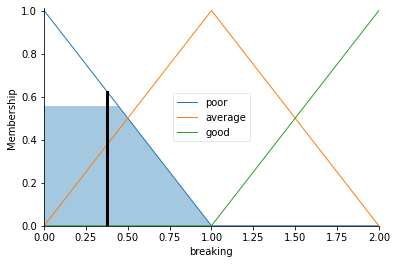

In [11]:
breaking.view(sim=breaking_force)

In [12]:
turning_force.input['distance_2'] = 2.6
turning_force.input['distance_3'] = 2.6

# Crunch the numbers
turning_force.compute()

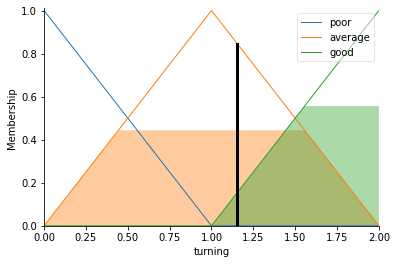

In [13]:
turning.view(sim=turning_force)

In [15]:
tank.forward(10)
while True:
    dist = []
    obj = []
    for i in range(8):
        err_code,detectionState,detectedPoint,detectedObjectHandle,detectedSurfaceNormalVector=vrep.simxReadProximitySensor(clientID,proximity_sensors_handles[i],vrep.simx_opmode_buffer)
        dist.append(np.linalg.norm(detectedPoint))
        if detectionState:
            obj.append(detectedObjectHandle)
        else:
            obj.append(-1)

    turning_force.input['distance_2'] = dist[2]
    turning_force.input['distance_3'] = dist[3]

    breaking_force.input['distance_3'] = dist[3]
    breaking_force.input['distance_4'] = dist[4]

    try:
        # Crunch the numbers
        turning_force.compute()
    except:
        pass
    try:
        # Crunch the numbers
        breaking_force.compute()
    except:
        pass

    if turning_force.output['turning'] > 1.1:
        print('right')
        tank.stop()
        tank.turn_right(10)
        time.sleep(4)
        # print(dist)
        tank.forward(5)

    if breaking_force.output['breaking'] > 1.6:
        print('stop')
        tank.stop()
        print('left')
        tank.turn_left(10)
        time.sleep(6.5)
        tank.stop()
        break

right
right
stop
left
